# Day 4 — Clustering: K-Means & Hierarchical Clustering

A complete walkthrough of Clustering (Unsupervised Learning) algorithms covering:
- **Part 1**: K-Means Clustering with Small Dataset (Step-by-Step Iterations)
- **Part 2**: K-Means Clustering on Real Dataset (Iris)
- **Part 3**: Hierarchical Clustering with Small Dataset
- **Part 4**: Hierarchical Clustering on Real Dataset (Iris)
- **Part 5**: AutoML Clustering with PyCaret

Each part includes visualisations of **cluster assignments**, **centroids**, and **evaluation metrics** (Silhouette Score, Inertia, Davies-Bouldin Index).

In [1]:
# ── Common Imports ──────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')



In [2]:
# Sklearn
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage

print('Libraries loaded successfully!')

Libraries loaded successfully!


---
# Part 1 — K-Means Clustering with Small Dataset

### What is K-Means?
K-Means is an **iterative** clustering algorithm that partitions data into **K clusters** by minimising the sum of squared distances between each point and its assigned **centroid**.

**Algorithm Steps:**
1. Choose K initial centroids randomly
2. Assign each point to the **nearest centroid**
3. Recalculate centroids as the **mean** of assigned points
4. Repeat steps 2–3 until centroids **converge** (stop moving)

$$J = \sum_{i=1}^{K} \sum_{x \in C_i} \|x - \mu_i\|^2$$

Where $\mu_i$ is the centroid of cluster $C_i$.

**Small Dataset:** We create a simple 2D dataset to visualise each iteration.

In [3]:
# ── Part 1: Create Small 2D Dataset ──────────────────────────────

np.random.seed(42)

# Create 3 well-separated clusters (4 points each = 12 total)
cluster_1 = np.random.randn(4, 2) + [2, 2]
cluster_2 = np.random.randn(4, 2) + [8, 8]
cluster_3 = np.random.randn(4, 2) + [5, 0]

X_small = np.vstack([cluster_1, cluster_2, cluster_3])
df_small = pd.DataFrame(X_small, columns=['Feature_1', 'Feature_2'])

print(df_small)

    Feature_1  Feature_2
0    2.496714   1.861736
1    2.647689   3.523030
2    1.765847   1.765863
3    3.579213   2.767435
4    7.530526   8.542560
5    7.536582   7.534270
6    8.241962   6.086720
7    6.275082   7.437712
8    3.987169   0.314247
9    4.091976  -1.412304
10   6.465649  -0.225776
11   5.067528  -1.424748


In [4]:
print('=== Small 2D Dataset (12 samples, 3 natural clusters) ===')
print(df_small.describe().round(2))

=== Small 2D Dataset (12 samples, 3 natural clusters) ===
       Feature_1  Feature_2
count      12.00      12.00
mean        4.97       3.06
std         2.20       3.57
min         1.77      -1.42
25%         3.35       0.18
50%         4.58       2.31
75%         6.73       6.42
max         8.24       8.54


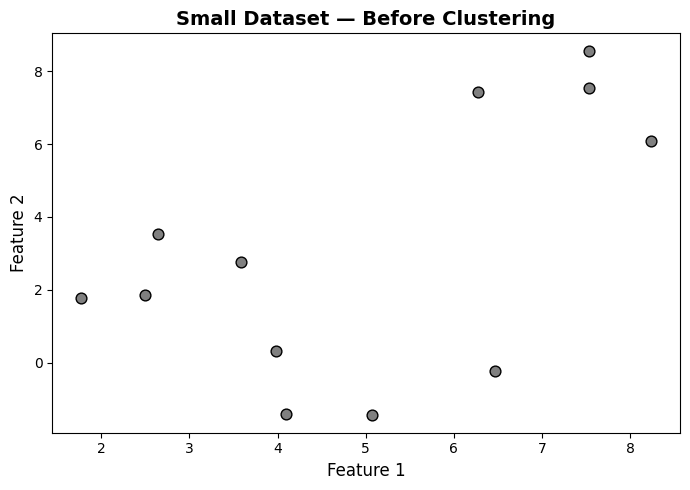

In [5]:
# ── Visualise the Raw Data ────────────────────────────────────────

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(X_small[:, 0], X_small[:, 1], c='gray', s=60, edgecolors='black')
ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('Small Dataset — Before Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Iteration 1: Centroid shift = 2.3681
  Centroid 0: (1.77, 1.77) → (3.76, 0.90)
  Centroid 1: (8.24, 6.09) → (8.24, 6.09)
  Centroid 2: (6.28, 7.44) → (7.11, 7.84)
Iteration 2: Centroid shift = 0.0000
  Centroid 0: (3.76, 0.90) → (3.76, 0.90)
  Centroid 1: (8.24, 6.09) → (8.24, 6.09)
  Centroid 2: (7.11, 7.84) → (7.11, 7.84)

Converged at iteration 2!


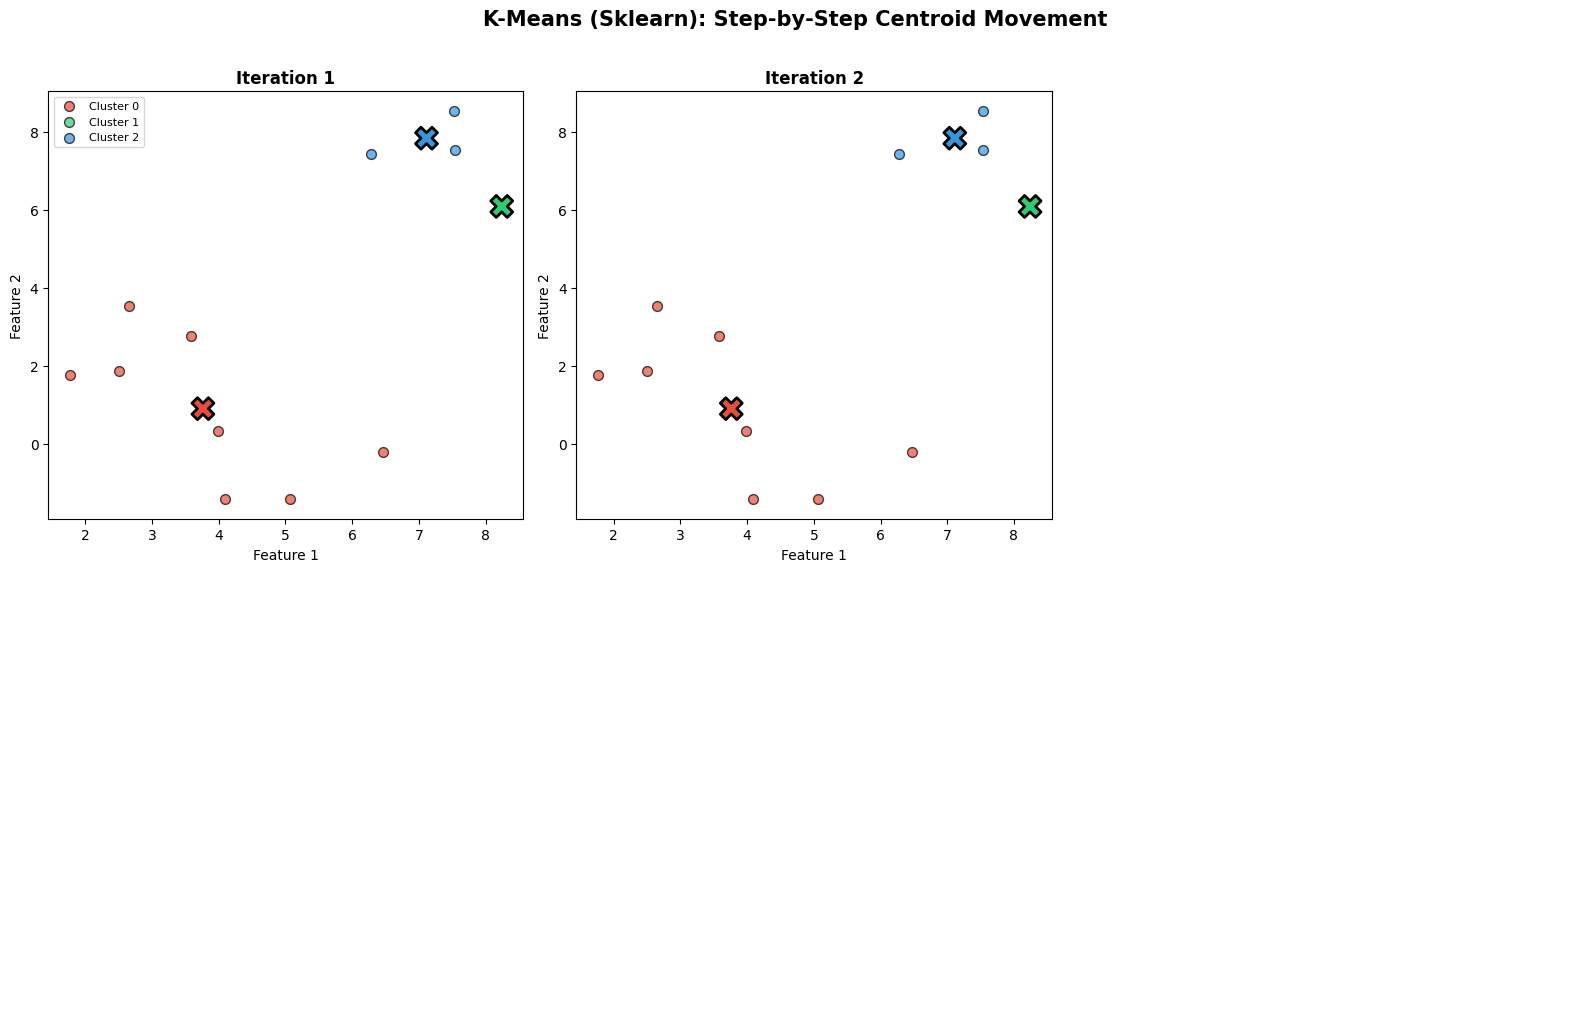

In [6]:
# ── K-Means Step-by-Step using Sklearn ────────────────────────────
#    We use KMeans with max_iter=1 repeatedly to visualise centroid movement

from sklearn.cluster import KMeans

K = 3
max_iters = 6

# Use a fixed random state and initial centroids
np.random.seed(10)
initial_indices = np.random.choice(len(X_small), K, replace=False)
init_centroids = X_small[initial_indices].copy()

colors = ['#e74c3c', '#2ecc71', '#3498db']  # red, green, blue
centroid_history = [init_centroids.copy()]
label_history = []

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

converged = False
for iteration in range(max_iters):
    # ── Run KMeans with max_iter = iteration+1 to get state at each step ──
    kmeans_iter = KMeans(n_clusters=K, init=init_centroids, n_init=1,
                         max_iter=iteration + 1, random_state=42)
    kmeans_iter.fit(X_small)

    labels = kmeans_iter.labels_
    centroids = kmeans_iter.cluster_centers_
    label_history.append(labels.copy())

    # ── Plot this iteration ──────────────────────────────────────
    ax = axes[iteration]
    for k in range(K):
        cluster_points = X_small[labels == k]
        ax.scatter(cluster_points[:, 0], cluster_points[:, 1],
                   c=colors[k], s=50, edgecolors='black', alpha=0.7,
                   label=f'Cluster {k}')

    # Plot centroids
    ax.scatter(centroids[:, 0], centroids[:, 1],
               c=colors[:K], s=250, marker='X', edgecolors='black',
               linewidths=2, zorder=5)

    # Draw arrows from previous to current centroid
    if iteration > 0:
        old_c = centroid_history[-1]
        for k in range(K):
            ax.annotate('', xy=centroids[k], xytext=old_c[k],
                        arrowprops=dict(arrowstyle='->', color='black',
                                        lw=1.5, ls='--'))

    ax.set_title(f'Iteration {iteration + 1}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')
    if iteration == 0:
        ax.legend(fontsize=8)

    # Check convergence
    shift = np.linalg.norm(centroids - centroid_history[-1])
    print(f'Iteration {iteration + 1}: Centroid shift = {shift:.4f}')
    for k in range(K):
        print(f'  Centroid {k}: ({centroid_history[-1][k][0]:.2f}, {centroid_history[-1][k][1]:.2f})'
              f' → ({centroids[k][0]:.2f}, {centroids[k][1]:.2f})')

    centroid_history.append(centroids.copy())

    if iteration > 0 and shift < 1e-4:
        print(f'\nConverged at iteration {iteration + 1}!')
        converged = True
        for j in range(iteration + 1, max_iters):
            axes[j].axis('off')
        break

if not converged:
    print(f'\nCompleted {max_iters} iterations.')

fig.suptitle('K-Means (Sklearn): Step-by-Step Centroid Movement', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

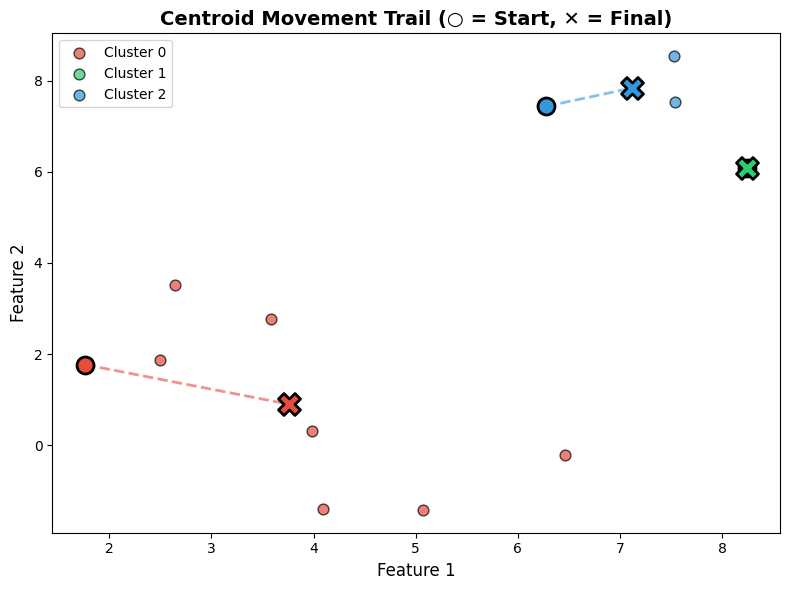

In [10]:
# ── Centroid Movement Trail ──────────────────────────────────────

fig, ax = plt.subplots(figsize=(8, 6))

# Plot final clusters
for k in range(K):
    cluster_points = X_small[labels == k]
    ax.scatter(cluster_points[:, 0], cluster_points[:, 1],
               c=colors[k], s=60, edgecolors='black', alpha=0.7,
               label=f'Cluster {k}')

# Plot centroid trail
for k in range(K):
    trail = np.array([ch[k] for ch in centroid_history])
    ax.plot(trail[:, 0], trail[:, 1], '--', color=colors[k], linewidth=2, alpha=0.6)
    ax.scatter(trail[0, 0], trail[0, 1], c=colors[k], s=150, marker='o',
               edgecolors='black', linewidths=2, zorder=5)
    ax.scatter(trail[-1, 0], trail[-1, 1], c=colors[k], s=250, marker='X',
               edgecolors='black', linewidths=2, zorder=5)

ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('Centroid Movement Trail (○ = Start, ✕ = Final)', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
# ── K-Means with Sklearn (verify) ────────────────────────────────

kmeans_small = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_small.fit(X_small)

labels_small = kmeans_small.labels_
centroids_small = kmeans_small.cluster_centers_

print('=== Sklearn K-Means Results ===')
print(f'Cluster labels: {labels_small}')
print(f'\nFinal Centroids:')
for i, c in enumerate(centroids_small):
    print(f'  Cluster {i}: ({c[0]:.2f}, {c[1]:.2f})')
print(f'\nInertia (WCSS): {kmeans_small.inertia_:.4f}')

=== Sklearn K-Means Results ===
Cluster labels: [2 2 2 2 0 0 0 0 1 1 1 1]

Final Centroids:
  Cluster 0: (7.40, 7.40)
  Cluster 1: (4.90, -0.69)
  Cluster 2: (2.62, 2.48)

Inertia (WCSS): 15.0390


In [12]:
# ── Evaluation Metrics — Part 1 ──────────────────────────────────

sil_small = silhouette_score(X_small, labels_small)
db_small = davies_bouldin_score(X_small, labels_small)

print('\n' + '─'*50)
print('  Part 1: K-Means — Small Dataset')
print('─'*50)
print(f'  Inertia (WCSS)     : {kmeans_small.inertia_:.4f}')
print(f'  Silhouette Score   : {sil_small:.4f}  (closer to 1 = better)')
print(f'  Davies-Bouldin Idx : {db_small:.4f}  (lower = better)')
print('─'*50)


──────────────────────────────────────────────────
  Part 1: K-Means — Small Dataset
──────────────────────────────────────────────────
  Inertia (WCSS)     : 15.0390
  Silhouette Score   : 0.6214  (closer to 1 = better)
  Davies-Bouldin Idx : 0.4631  (lower = better)
──────────────────────────────────────────────────


---
# Part 2 — K-Means Clustering on Real Dataset (Iris)

The **Iris dataset** from sklearn has 150 samples, 4 features (sepal length, sepal width, petal length, petal width) and 3 species. We ignore the true labels and let K-Means discover clusters on its own.

### Steps:
1. Load `load_iris()` from sklearn
2. Scale features with `StandardScaler`
3. Use the **Elbow Method** to choose optimal K
4. Fit K-Means and visualise

In [15]:
# ── Part 2: Load Iris Dataset ─────────────────────────────────────

iris = load_iris()
X_iris = iris.data
feature_names = iris.feature_names
true_labels = iris.target
target_names = iris.target_names

df_iris = pd.DataFrame(X_iris, columns=feature_names)

print('=== Iris Dataset ===')
print(df_iris.head())
print(f'\nShape: {df_iris.shape}')
print(f'Features: {feature_names}')
print(f'True classes (ignored for clustering): {list(target_names)}')
print(f'\nBasic Stats:')
print(df_iris.describe().round(2))

=== Iris Dataset ===
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Shape: (150, 4)
Features: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
True classes (ignored for clustering): [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

Basic Stats:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count             150.00            150.00             150.00   
mean                5.84              3.06               3.76   
std                 0.83              0.44               1.77   
min                 4.30           

In [16]:
# ── Feature Scaling ──────────────────────────────────────────────

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)

print('=== After Scaling (first 5 rows) ===')
print(pd.DataFrame(X_scaled, columns=feature_names).head().round(3))

=== After Scaling (first 5 rows) ===
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0             -0.901             1.019             -1.340            -1.315
1             -1.143            -0.132             -1.340            -1.315
2             -1.385             0.328             -1.397            -1.315
3             -1.507             0.098             -1.283            -1.315
4             -1.022             1.249             -1.340            -1.315


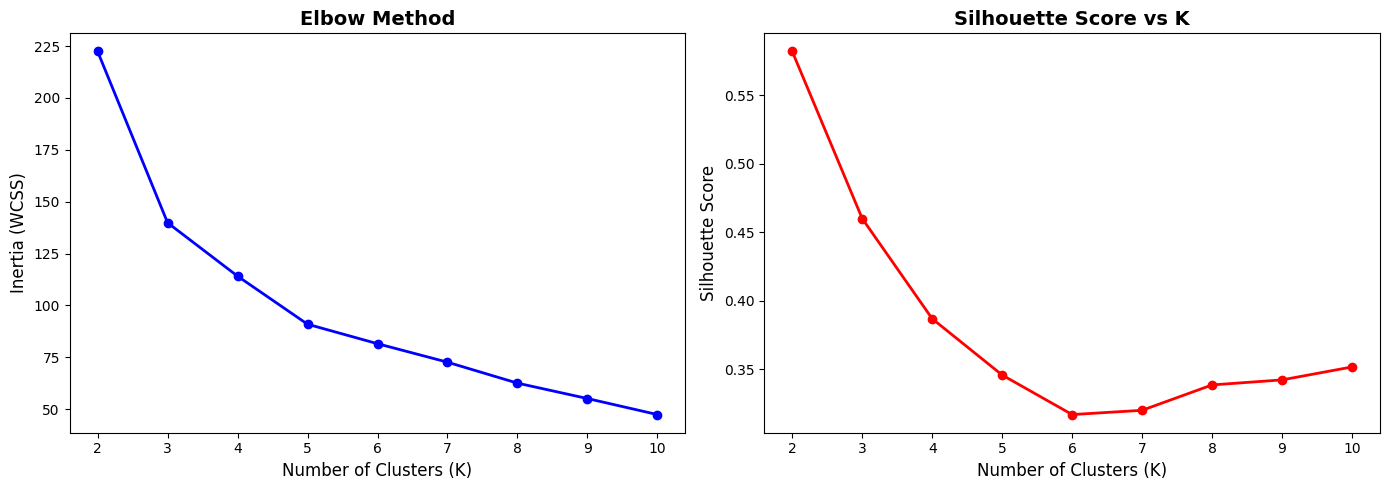

Best K by Silhouette Score: 2


In [17]:
# ── Elbow Method to Find Optimal K ───────────────────────────────

inertias = []
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(K_range, inertias, 'bo-', linewidth=2)
ax1.set_xlabel('Number of Clusters (K)', fontsize=12)
ax1.set_ylabel('Inertia (WCSS)', fontsize=12)
ax1.set_title('Elbow Method', fontsize=14, fontweight='bold')
ax1.set_xticks(list(K_range))

# Silhouette plot
ax2.plot(K_range, sil_scores, 'ro-', linewidth=2)
ax2.set_xlabel('Number of Clusters (K)', fontsize=12)
ax2.set_ylabel('Silhouette Score', fontsize=12)
ax2.set_title('Silhouette Score vs K', fontsize=14, fontweight='bold')
ax2.set_xticks(list(K_range))

plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(sil_scores)]
print(f'Best K by Silhouette Score: {best_k}')

In [18]:
# ── K-Means on Iris ──────────────────────────────────────────────

kmeans_iris = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans_iris.fit(X_scaled)

cluster_labels_iris = kmeans_iris.labels_
df_iris['Cluster'] = cluster_labels_iris

print('=== K-Means (K=3) — Cluster Distribution ===')
print(df_iris['Cluster'].value_counts().sort_index())

print(f'\n=== Cluster Centroids (original scale) ===')
centroids_original = scaler.inverse_transform(kmeans_iris.cluster_centers_)
centroids_df = pd.DataFrame(centroids_original, columns=feature_names)
centroids_df.index.name = 'Cluster'
print(centroids_df.round(2))

=== K-Means (K=3) — Cluster Distribution ===
Cluster
0    53
1    50
2    47
Name: count, dtype: int64

=== Cluster Centroids (original scale) ===
         sepal length (cm)  sepal width (cm)  petal length (cm)  \
Cluster                                                           
0                     5.80              2.67               4.37   
1                     5.01              3.43               1.46   
2                     6.78              3.10               5.51   

         petal width (cm)  
Cluster                    
0                    1.41  
1                    0.25  
2                    1.97  


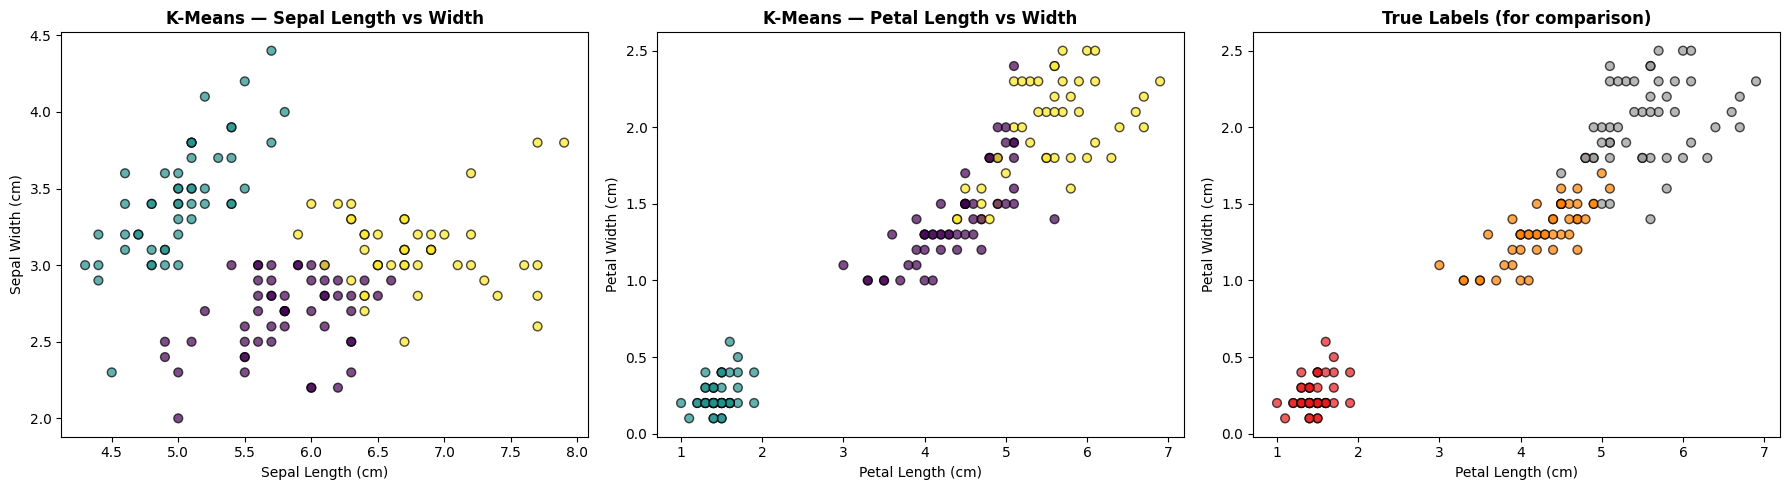

In [19]:
# ── Cluster Visualisation (Iris) ─────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Sepal Length vs Sepal Width
axes[0].scatter(df_iris['sepal length (cm)'], df_iris['sepal width (cm)'],
                c=cluster_labels_iris, cmap='viridis', s=40, alpha=0.7, edgecolors='black')
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')
axes[0].set_title('K-Means — Sepal Length vs Width', fontweight='bold')

# Petal Length vs Petal Width
axes[1].scatter(df_iris['petal length (cm)'], df_iris['petal width (cm)'],
                c=cluster_labels_iris, cmap='viridis', s=40, alpha=0.7, edgecolors='black')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].set_title('K-Means — Petal Length vs Width', fontweight='bold')

# Compare with true labels
axes[2].scatter(df_iris['petal length (cm)'], df_iris['petal width (cm)'],
                c=true_labels, cmap='Set1', s=40, alpha=0.7, edgecolors='black')
axes[2].set_xlabel('Petal Length (cm)')
axes[2].set_ylabel('Petal Width (cm)')
axes[2].set_title('True Labels (for comparison)', fontweight='bold')

plt.tight_layout()
plt.show()

In [20]:
# ── Evaluation Metrics — Part 2 ──────────────────────────────────

sil_iris = silhouette_score(X_scaled, cluster_labels_iris)
db_iris = davies_bouldin_score(X_scaled, cluster_labels_iris)

print('\n' + '─'*50)
print('  Part 2: K-Means (K=3) — Iris Dataset')
print('─'*50)
print(f'  Inertia (WCSS)     : {kmeans_iris.inertia_:.4f}')
print(f'  Silhouette Score   : {sil_iris:.4f}')
print(f'  Davies-Bouldin Idx : {db_iris:.4f}')
print('─'*50)


──────────────────────────────────────────────────
  Part 2: K-Means (K=3) — Iris Dataset
──────────────────────────────────────────────────
  Inertia (WCSS)     : 139.8205
  Silhouette Score   : 0.4599
  Davies-Bouldin Idx : 0.8336
──────────────────────────────────────────────────


---
# Part 3 — Hierarchical Clustering with Small Dataset

### What is Hierarchical Clustering?
Hierarchical Clustering builds a **tree of clusters** (dendrogram). Two approaches:
- **Agglomerative** (bottom-up): Start with each point as its own cluster, merge closest pairs
- **Divisive** (top-down): Start with one cluster, split recursively

We use **Agglomerative Clustering** with different linkage methods:
- **Single linkage** — minimum distance between clusters
- **Complete linkage** — maximum distance between clusters
- **Ward's method** — minimises total within-cluster variance

We reuse the same **small 2D dataset** from Part 1.

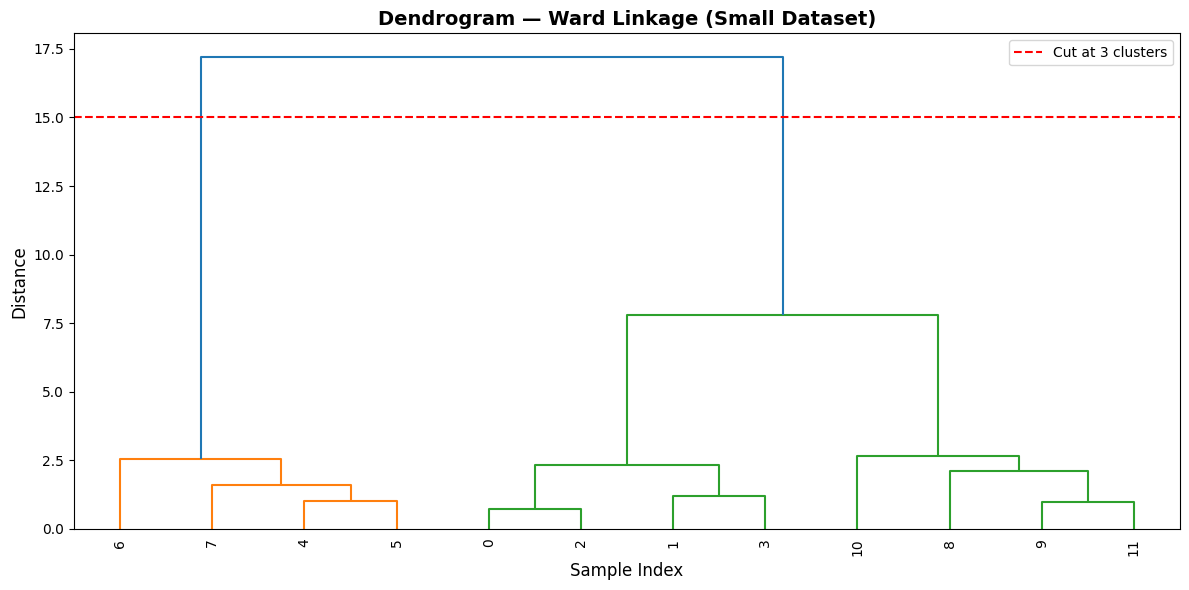

In [21]:
# ── Part 3: Dendrogram — Small Dataset ───────────────────────────

# Compute linkage matrix
linkage_ward = linkage(X_small, method='ward')

fig, ax = plt.subplots(figsize=(12, 6))
dendrogram(linkage_ward,
           leaf_rotation=90,
           leaf_font_size=10,
           ax=ax)
ax.set_xlabel('Sample Index', fontsize=12)
ax.set_ylabel('Distance', fontsize=12)
ax.set_title('Dendrogram — Ward Linkage (Small Dataset)', fontsize=14, fontweight='bold')
ax.axhline(y=15, color='red', linestyle='--', label='Cut at 3 clusters')
ax.legend()
plt.tight_layout()
plt.show()

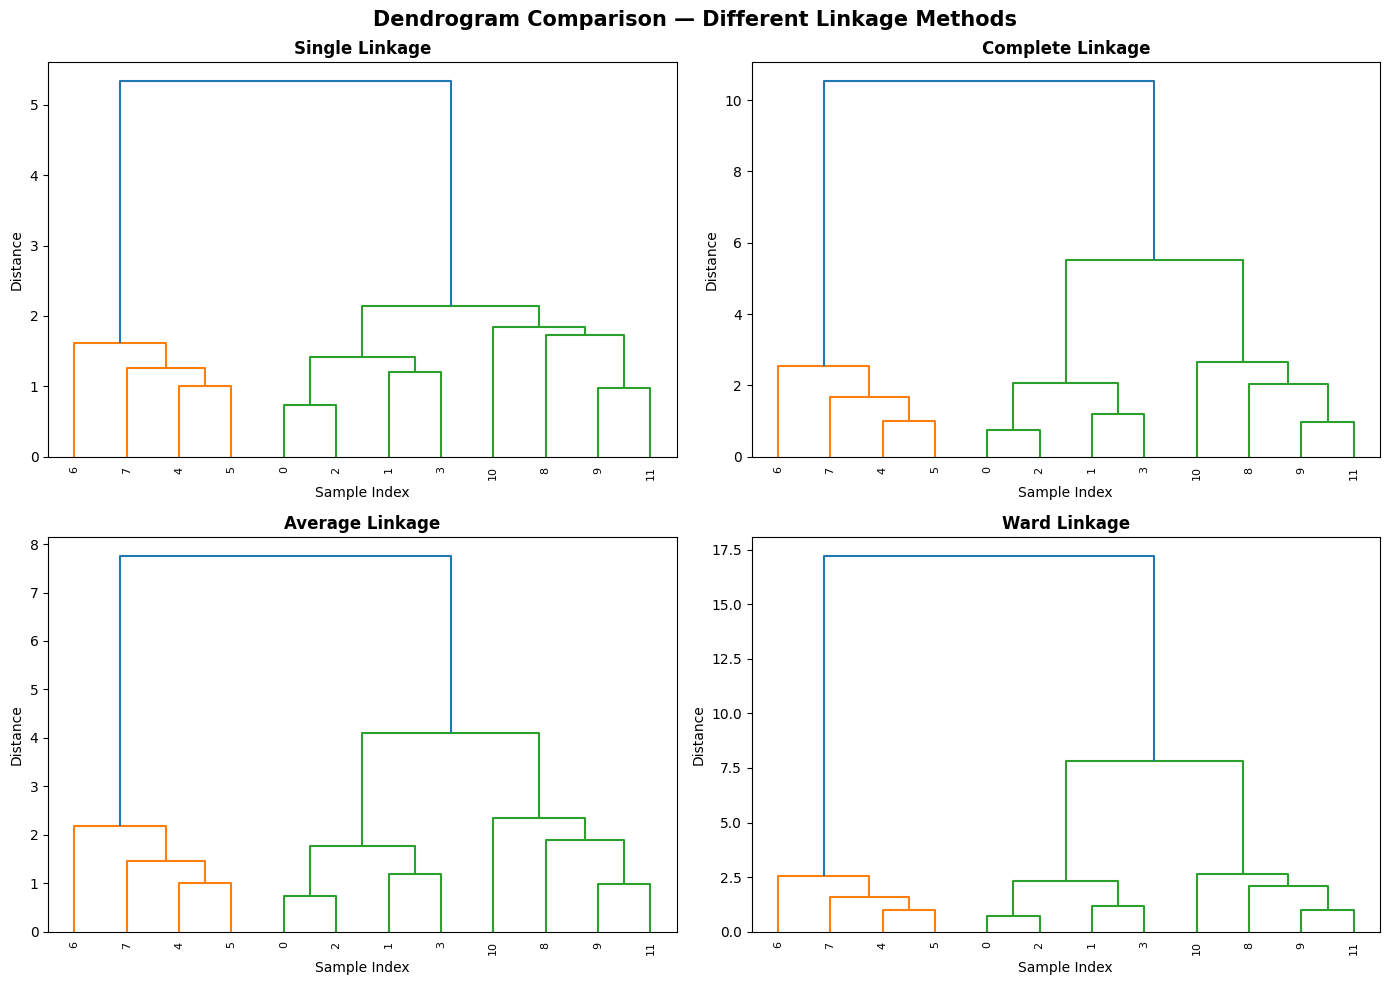

In [22]:
# ── Compare Linkage Methods ──────────────────────────────────────

methods = ['single', 'complete', 'average', 'ward']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, method in enumerate(methods):
    Z = linkage(X_small, method=method)
    dendrogram(Z, leaf_rotation=90, leaf_font_size=8, ax=axes[i])
    axes[i].set_title(f'{method.capitalize()} Linkage', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Sample Index')
    axes[i].set_ylabel('Distance')

fig.suptitle('Dendrogram Comparison — Different Linkage Methods', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

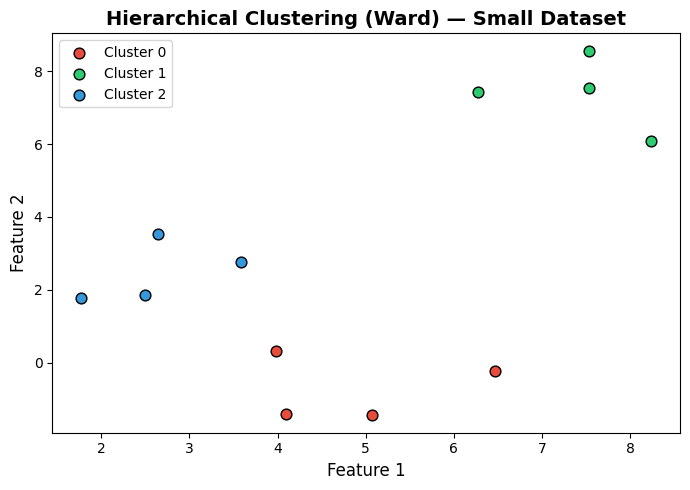

Cluster distribution: {0: 4, 1: 4, 2: 4}


In [23]:
# ── Agglomerative Clustering (Small Dataset) ─────────────────────

agg_small = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels_small = agg_small.fit_predict(X_small)

fig, ax = plt.subplots(figsize=(7, 5))
for k in range(3):
    cluster_pts = X_small[agg_labels_small == k]
    ax.scatter(cluster_pts[:, 0], cluster_pts[:, 1],
               c=colors[k], s=60, edgecolors='black', label=f'Cluster {k}')

ax.set_xlabel('Feature 1', fontsize=12)
ax.set_ylabel('Feature 2', fontsize=12)
ax.set_title('Hierarchical Clustering (Ward) — Small Dataset', fontsize=14, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Cluster distribution: {pd.Series(agg_labels_small).value_counts().sort_index().to_dict()}')

In [24]:
# ── Evaluation Metrics — Part 3 ──────────────────────────────────

sil_agg_small = silhouette_score(X_small, agg_labels_small)
db_agg_small = davies_bouldin_score(X_small, agg_labels_small)

print('\n' + '─'*50)
print('  Part 3: Hierarchical Clustering — Small Dataset')
print('─'*50)
print(f'  Silhouette Score   : {sil_agg_small:.4f}')
print(f'  Davies-Bouldin Idx : {db_agg_small:.4f}')
print('─'*50)


──────────────────────────────────────────────────
  Part 3: Hierarchical Clustering — Small Dataset
──────────────────────────────────────────────────
  Silhouette Score   : 0.6214
  Davies-Bouldin Idx : 0.4631
──────────────────────────────────────────────────


---
# Part 4 — Hierarchical Clustering on Real Dataset (Iris)

We apply **Agglomerative Clustering** on the same scaled **Iris dataset** from Part 2.

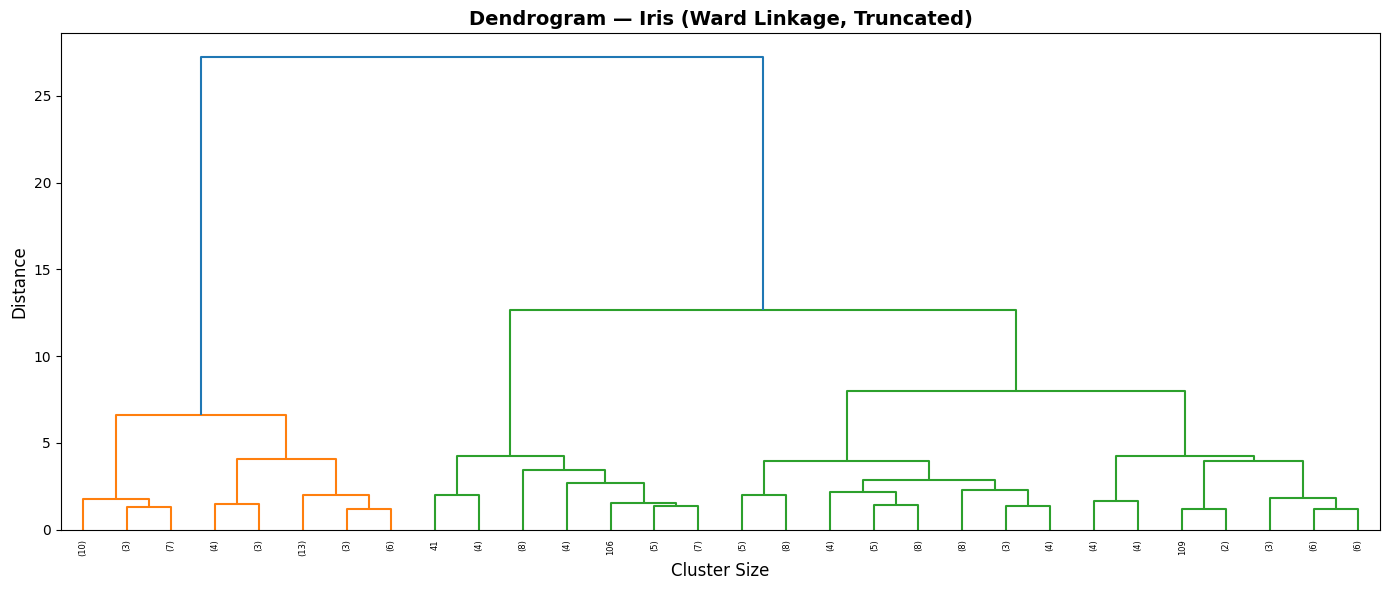

In [25]:
# ── Part 4: Dendrogram — Iris Dataset ────────────────────────────

linkage_iris = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(linkage_iris,
           leaf_rotation=90,
           leaf_font_size=6,
           truncate_mode='lastp',
           p=30,
           ax=ax)
ax.set_xlabel('Cluster Size', fontsize=12)
ax.set_ylabel('Distance', fontsize=12)
ax.set_title('Dendrogram — Iris (Ward Linkage, Truncated)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

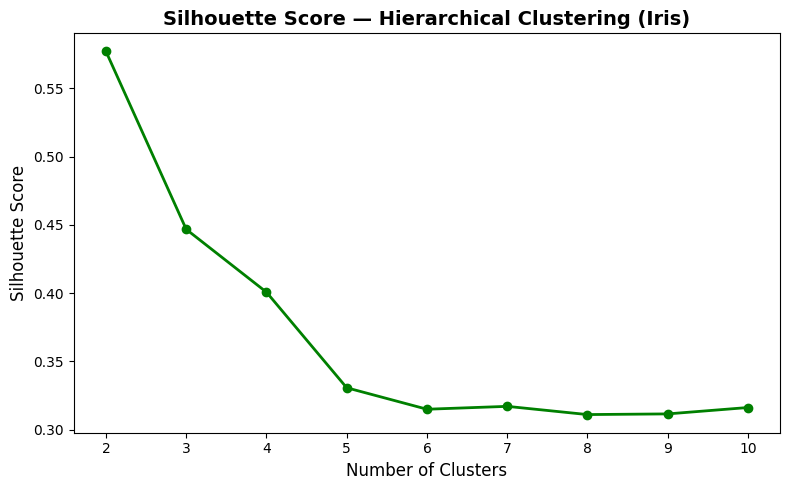

Best K by Silhouette Score: 2


In [26]:
# ── Find Optimal Number of Clusters ──────────────────────────────

sil_scores_agg = []
K_range_agg = range(2, 11)

for k in K_range_agg:
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    agg_labels = agg.fit_predict(X_scaled)
    sil_scores_agg.append(silhouette_score(X_scaled, agg_labels))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(K_range_agg, sil_scores_agg, 'go-', linewidth=2)
ax.set_xlabel('Number of Clusters', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Silhouette Score — Hierarchical Clustering (Iris)', fontsize=14, fontweight='bold')
ax.set_xticks(list(K_range_agg))
plt.tight_layout()
plt.show()

best_k_agg = K_range_agg[np.argmax(sil_scores_agg)]
print(f'Best K by Silhouette Score: {best_k_agg}')

In [27]:
# ── Agglomerative Clustering on Iris ─────────────────────────────

agg_iris = AgglomerativeClustering(n_clusters=3, linkage='ward')
agg_labels_iris = agg_iris.fit_predict(X_scaled)

df_iris['HC_Cluster'] = agg_labels_iris

print('=== Hierarchical Clustering (K=3) — Cluster Distribution ===')
print(df_iris['HC_Cluster'].value_counts().sort_index())

# Cluster profiles
print(f'\n=== Cluster Profiles (Mean Values) ===')
profile = df_iris.groupby('HC_Cluster')[feature_names].mean().round(2)
print(profile)

=== Hierarchical Clustering (K=3) — Cluster Distribution ===
HC_Cluster
0    71
1    49
2    30
Name: count, dtype: int64

=== Cluster Profiles (Mean Values) ===
            sepal length (cm)  sepal width (cm)  petal length (cm)  \
HC_Cluster                                                           
0                        6.55              2.99               5.27   
1                        5.02              3.45               1.47   
2                        5.53              2.57               3.93   

            petal width (cm)  
HC_Cluster                    
0                       1.85  
1                       0.24  
2                       1.21  


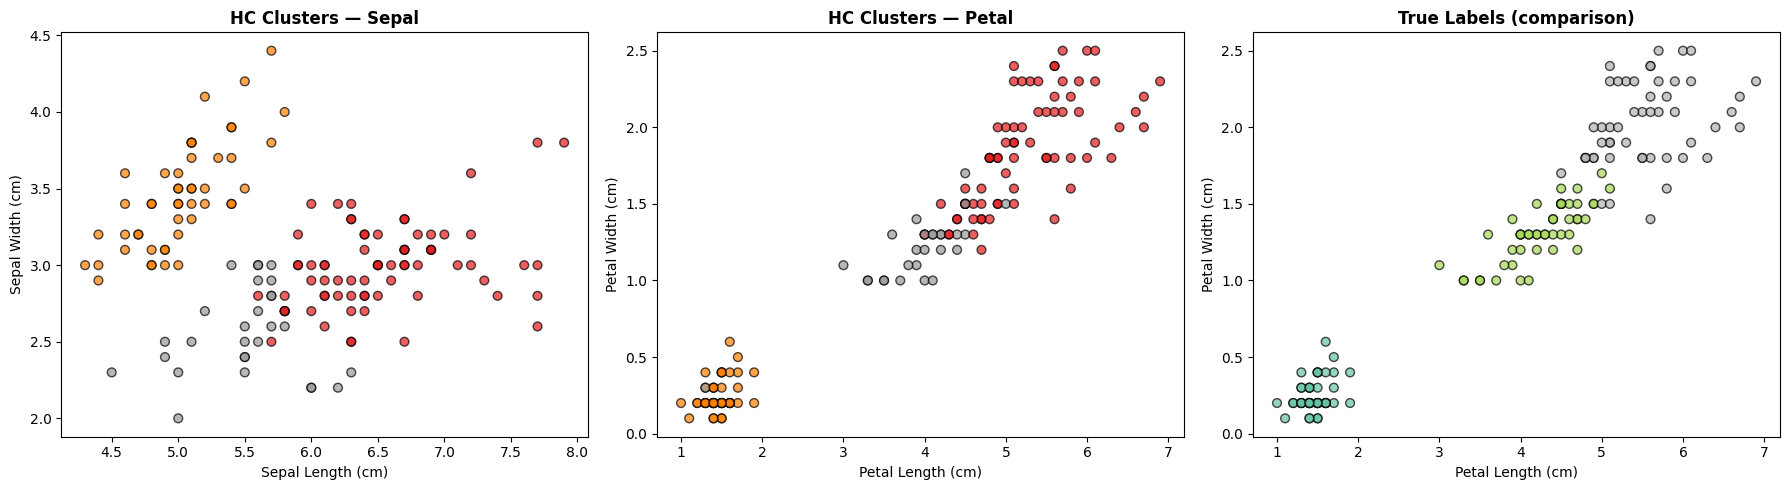

In [28]:
# ── Cluster Visualisation (Hierarchical — Iris) ──────────────────

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# HC clusters — Sepal
axes[0].scatter(df_iris['sepal length (cm)'], df_iris['sepal width (cm)'],
                c=agg_labels_iris, cmap='Set1', s=40, alpha=0.7, edgecolors='black')
axes[0].set_xlabel('Sepal Length (cm)')
axes[0].set_ylabel('Sepal Width (cm)')
axes[0].set_title('HC Clusters — Sepal', fontweight='bold')

# HC clusters — Petal
axes[1].scatter(df_iris['petal length (cm)'], df_iris['petal width (cm)'],
                c=agg_labels_iris, cmap='Set1', s=40, alpha=0.7, edgecolors='black')
axes[1].set_xlabel('Petal Length (cm)')
axes[1].set_ylabel('Petal Width (cm)')
axes[1].set_title('HC Clusters — Petal', fontweight='bold')

# True labels for comparison
axes[2].scatter(df_iris['petal length (cm)'], df_iris['petal width (cm)'],
                c=true_labels, cmap='Set2', s=40, alpha=0.7, edgecolors='black')
axes[2].set_xlabel('Petal Length (cm)')
axes[2].set_ylabel('Petal Width (cm)')
axes[2].set_title('True Labels (comparison)', fontweight='bold')

plt.tight_layout()
plt.show()

In [29]:
# ── Evaluation Metrics — Part 4 ──────────────────────────────────

sil_agg_iris = silhouette_score(X_scaled, agg_labels_iris)
db_agg_iris = davies_bouldin_score(X_scaled, agg_labels_iris)

print('\n' + '─'*50)
print('  Part 4: Hierarchical Clustering (K=3) — Iris')
print('─'*50)
print(f'  Silhouette Score   : {sil_agg_iris:.4f}')
print(f'  Davies-Bouldin Idx : {db_agg_iris:.4f}')
print('─'*50)


──────────────────────────────────────────────────
  Part 4: Hierarchical Clustering (K=3) — Iris
──────────────────────────────────────────────────
  Silhouette Score   : 0.4467
  Davies-Bouldin Idx : 0.8035
──────────────────────────────────────────────────


---
## Model Comparison — K-Means vs Hierarchical (Iris)

Side-by-side comparison of both clustering methods on the same dataset.

=== Clustering Model Comparison — Iris ===
       Model  K  Silhouette  Davies-Bouldin Inertia
     K-Means  3      0.4599          0.8336  139.82
Hierarchical  3      0.4467          0.8035       —


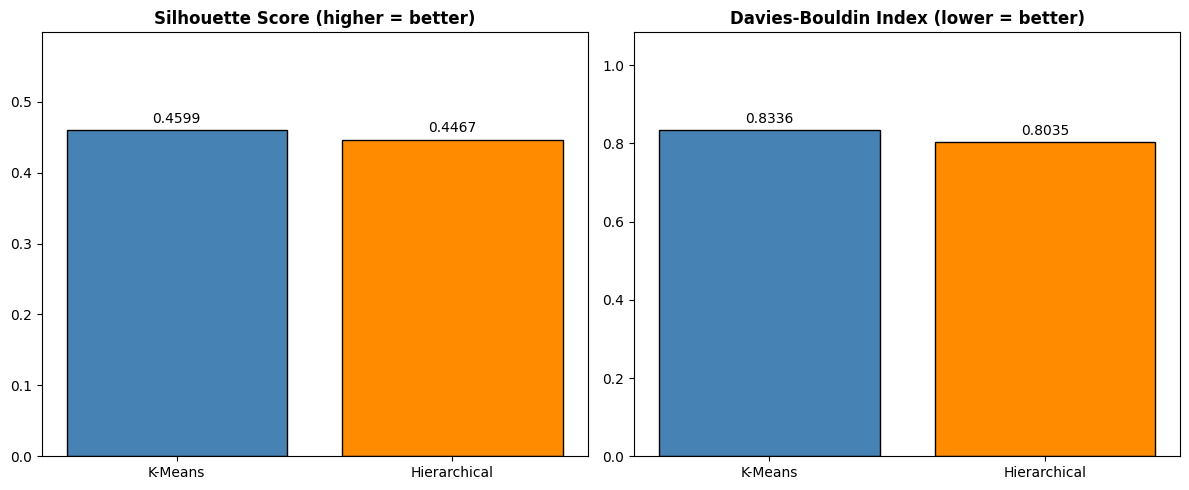

In [30]:
# ── Side-by-side Comparison ──────────────────────────────────────

comp_rows = [
    ['K-Means', 3, round(sil_iris, 4), round(db_iris, 4), round(kmeans_iris.inertia_, 2)],
    ['Hierarchical', 3, round(sil_agg_iris, 4), round(db_agg_iris, 4), '—'],
]

comparison_df = pd.DataFrame(comp_rows, columns=['Model', 'K', 'Silhouette', 'Davies-Bouldin', 'Inertia'])
print('=== Clustering Model Comparison — Iris ===')
print(comparison_df.to_string(index=False))

# Bar chart
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

models_comp = ['K-Means', 'Hierarchical']
sil_vals = [sil_iris, sil_agg_iris]
db_vals = [db_iris, db_agg_iris]

bars1 = ax1.bar(models_comp, sil_vals, color=['steelblue', 'darkorange'], edgecolor='black')
ax1.set_title('Silhouette Score (higher = better)', fontweight='bold')
ax1.set_ylim(0, max(sil_vals) * 1.3)
ax1.bar_label(bars1, fmt='%.4f', padding=3)

bars2 = ax2.bar(models_comp, db_vals, color=['steelblue', 'darkorange'], edgecolor='black')
ax2.set_title('Davies-Bouldin Index (lower = better)', fontweight='bold')
ax2.set_ylim(0, max(db_vals) * 1.3)
ax2.bar_label(bars2, fmt='%.4f', padding=3)

plt.tight_layout()
plt.show()

---
# Part 5 — AutoML Clustering with PyCaret

**PyCaret** can also perform **unsupervised clustering** — it handles preprocessing automatically and lets you compare multiple clustering algorithms.

> **Note:** If PyCaret is not installed, uncomment and run the install cell first.

In [1]:
# ── Install PyCaret (run only once) ──────────────────────────────
# Uncomment and run this cell if pycaret is not yet installed:

# import subprocess, sys
# subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'pycaret', '-q'])
print('If PyCaret is not installed, uncomment the lines above and run this cell first.')

If PyCaret is not installed, uncomment the lines above and run this cell first.


In [3]:
# ── PyCaret Data Loading ─────────────────────────────────────────

from sklearn.datasets import load_iris
import pandas as pd
iris_pyc = load_iris()
df_pyc = pd.DataFrame(iris_pyc.data, columns=iris_pyc.feature_names)

print('=== PyCaret Input Data ===')
print(df_pyc.head())
print(f'\nShape: {df_pyc.shape}')
print(f'\nColumns: {list(df_pyc.columns)}')

=== PyCaret Input Data ===
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Shape: (150, 4)

Columns: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [4]:
# ── PyCaret Clustering Setup ─────────────────────────────────────

from pycaret.clustering import (
    setup, create_model, assign_model, pull,
    plot_model, predict_model
)

clust_setup = setup(
    data        = df_pyc,
    session_id  = 42,
    normalize   = True,
    verbose     = False
)

print('PyCaret clustering setup complete!')

PyCaret clustering setup complete!


In [5]:
# ── Create K-Means Model (PyCaret) ───────────────────────────────

kmeans_pyc = create_model('kmeans', num_clusters=3)

print('=== K-Means Results (PyCaret) ===')
print(pull())

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4799,157.3602,0.7894,0,0,0


=== K-Means Results (PyCaret) ===
   Silhouette  Calinski-Harabasz  Davies-Bouldin  Homogeneity  Rand Index  \
0      0.4799           157.3602          0.7894            0           0   

   Completeness  
0             0  


In [6]:
# ── Assign Cluster Labels to Data ────────────────────────────────

result_kmeans = assign_model(kmeans_pyc)

print('=== Data with Cluster Assignments ===')
print(result_kmeans.head())
print(f'\nCluster Distribution:')
print(result_kmeans['Cluster'].value_counts().sort_index())

=== Data with Cluster Assignments ===
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

     Cluster  
0  Cluster 1  
1  Cluster 2  
2  Cluster 2  
3  Cluster 2  
4  Cluster 1  

Cluster Distribution:
Cluster
Cluster 0    96
Cluster 1    33
Cluster 2    21
Name: count, dtype: int64


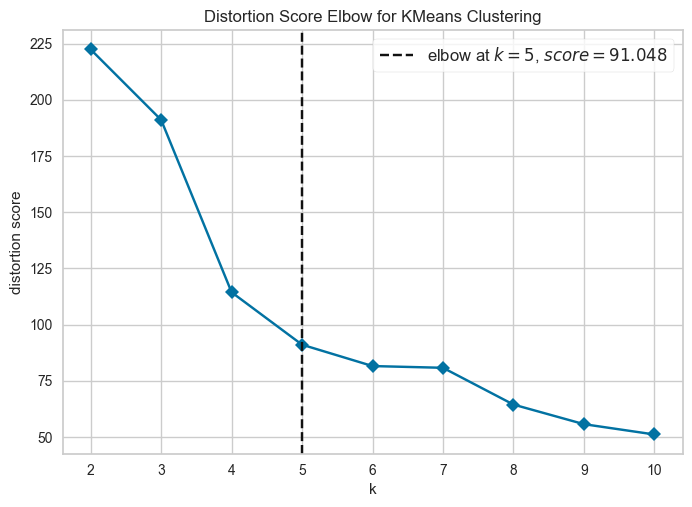

In [7]:
# ── PyCaret Cluster Visualisation — Elbow Plot ───────────────────

plot_model(kmeans_pyc, plot='elbow')

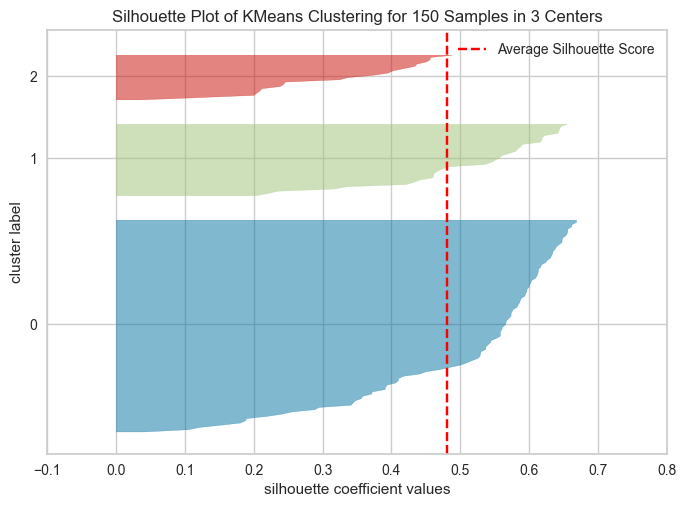

In [8]:
# ── PyCaret Cluster Visualisation — Silhouette Plot ──────────────

plot_model(kmeans_pyc, plot='silhouette')

In [9]:
# ── PyCaret Cluster Visualisation — Distribution Plot ────────────

plot_model(kmeans_pyc, plot='distribution')

In [10]:
# ── Create Hierarchical Model (PyCaret) ──────────────────────────

hc_pyc = create_model('hclust', num_clusters=3)

print('=== Hierarchical Clustering Results (PyCaret) ===')
print(pull())

,Silhouette,Calinski-Harabasz,Davies-Bouldin,Homogeneity,Rand Index,Completeness
0,0.4467,222.7191,0.8035,0,0,0


=== Hierarchical Clustering Results (PyCaret) ===
   Silhouette  Calinski-Harabasz  Davies-Bouldin  Homogeneity  Rand Index  \
0      0.4467           222.7191          0.8035            0           0   

   Completeness  
0             0  


In [12]:
# ── PyCaret Hierarchical — Distribution ──────────────────────────

print('=== Distribution — Hierarchical ===')
plot_model(hc_pyc, plot='distribution')

=== Distribution — Hierarchical ===


---
## Summary

| Part | Algorithm | Dataset | Key Takeaway |
|------|-----------|---------|---------------|
| 1 | K-Means | Small 2D (12 pts) | Centroids converge in few iterations; easy to visualise |
| 2 | K-Means | Iris (150 rows) | Elbow + Silhouette to pick K; clusters match species |
| 3 | Hierarchical | Small 2D (12 pts) | Dendrogram shows merge hierarchy; Ward works best |
| 4 | Hierarchical | Iris (150 rows) | No need to predefine K; cut dendrogram at desired level |
| 5 | PyCaret AutoML | Iris (150 rows) | One-line model creation; built-in plots |

### Key Concepts Recap
- **Inertia (WCSS)** — within-cluster sum of squares; lower = tighter clusters
- **Silhouette Score** — measures how similar a point is to its own cluster vs other clusters ($-1$ to $1$; higher = better)
- **Davies-Bouldin Index** — ratio of within-cluster to between-cluster distances; lower = better
- **Elbow Method** — plot inertia vs K; look for the "elbow" bend
- **Dendrogram** — tree diagram showing cluster merge order and distances
- **K-Means** — fast, needs K upfront, sensitive to initial centroids
- **Hierarchical** — no need to choose K upfront, produces dendrogram, slower on large data